In [44]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [45]:
D = 1
x0 = 1
x_target = 0
dt = 1e-3
max_time = 10
n_trials = 1000
np.random.seed(42)

In [46]:
def mfpt_theory(lam):
    return np.exp(x0*np.sqrt(2*lam/D - 1))/lam 

In [47]:
z_star = 1.59362426
lam_star = D*z_star**2/(2*x0**2)

In [48]:
def gen_fpts_exp(lam, n = n_trials, D = D, x0 = x0):
    fpts = np.zeros(n)

    for i in tqdm(range(n), desc = f"λ = {lam: .4f}"):

        t = 0
        fpt_found = False
        while t < max_time:
            x=x0

            reset = np.random.exponential(1/lam)
            t_loc = 0
            while t_loc < reset:

                x += np.sqrt(2*D*dt)*np.random.normal()
                t_loc += dt
                t += dt

                if x <= x_target:
                    fpts[i] = t
                    fpt_found = True
                    break

                if t >= max_time:
                    break
            
            if fpt_found:
                break
        
       
    
    return fpts

def gen_fpts_par(alpha, n, D, x0):
    fpts = np.zeros(n)

    for i in tqdm(range(n), desc = f"α = {alpha: .4f}"):

        t = 0
        fpt_found = False
        while t < max_time:
            x=x0

            reset = np.random.exponential(alpha)
            t_loc = 0
            while t_loc < reset:

                x += np.sqrt(2*D*dt)*np.random.normal()
                t_loc += dt
                t += dt

                if x <= x_target:
                    fpts[i] = t
                    fpt_found = True
                    break

                if t < max_time:
                    break
            
            if fpt_found:
                break
        
       
    
    return fpts

In [49]:
lambdas = np.linspace(0, 5, 20)
mfpt_sim = np.zeros(len(lambdas))
mfpt_err = np.zeros(len(lambdas))
mfpt_the = np.zeros(len(lambdas))

In [50]:
for idx, lam in enumerate(lambdas):
    fpts = gen_fpts_exp(lam)
    valid = fpts[fpts > 0]
    n_timeouts = n_trials - len(valid)
    mfpt_sim[idx] = np.mean(valid)
    mfpt_err[idx] = np.std(valid)/np.sqrt(len(valid))
    mfpt_the[idx] = mfpt_theory(lam)
    print(f"λ={lam:.4f}  MFPT_sim={mfpt_sim[idx]:.3f}  MFPT_theory={mfpt_the[idx]:.3f}")

print("how many timeouts", n_timeouts)

λ =  0.0000:   0%|          | 0/1000 [00:00<?, ?it/s]

C:\Users\bartek\AppData\Local\Temp\ipykernel_13904\3204952837.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  reset = np.random.exponential(1/lam)
λ =  0.0000: 100%|██████████| 1000/1000 [00:06<00:00, 147.11it/s]
C:\Users\bartek\AppData\Local\Temp\ipykernel_13904\2597771360.py:2: RuntimeWarning: invalid value encountered in sqrt
  return np.exp(x0*np.sqrt(2*lam/D - 1))/lam


λ=0.0000  MFPT_sim=1.608  MFPT_theory=nan


λ =  0.2632: 100%|██████████| 1000/1000 [00:06<00:00, 157.83it/s]


λ=0.2632  MFPT_sim=2.009  MFPT_theory=nan


...

λ=4.4737  MFPT_sim=1.701  MFPT_theory=3.747


λ =  4.7368: 100%|██████████| 1000/1000 [00:03<00:00, 264.45it/s]


λ=4.7368  MFPT_sim=1.742  MFPT_theory=3.879


λ =  5.0000: 100%|██████████| 1000/1000 [00:03<00:00, 256.82it/s]

λ=5.0000  MFPT_sim=1.804  MFPT_theory=4.017
how many timeouts 2


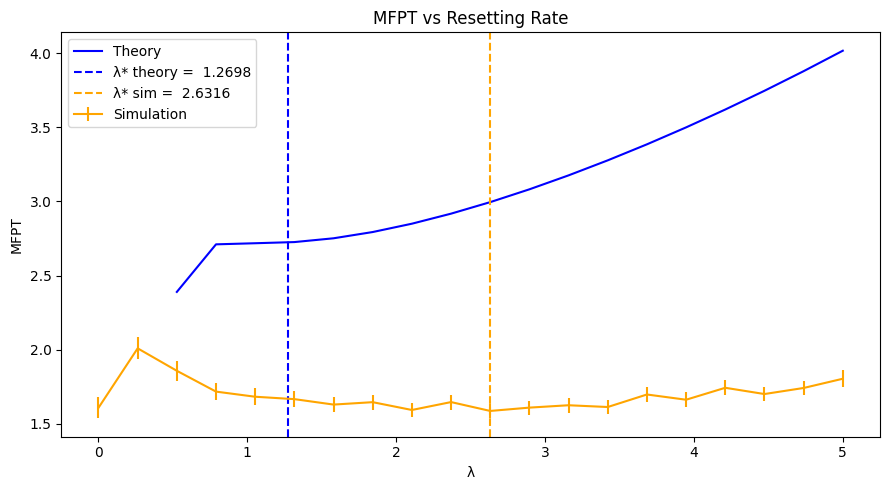

In [53]:
lam_opt_sim = lambdas[np.argmin(mfpt_sim)]

plt.figure(figsize=(9, 5))
plt.plot(lambdas, mfpt_the, label = "Theory", color = "blue")
plt.errorbar(lambdas, mfpt_sim, yerr = mfpt_err, label = "Simulation", color = "orange")
plt.axvline(lam_star, color = "blue", linestyle = '--', label = f"λ* theory = {lam_star: .4f}")
plt.axvline(lam_opt_sim, color = "orange", linestyle = '--', label =f"λ* sim = {lam_opt_sim: .4f}")
plt.xlabel("λ")
plt.ylabel("MFPT")
plt.title("MFPT vs Resetting Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
fpts_test = gen_fpts_exp(lam_star, n=100, D=D, x0=x0)
valid = fpts_test[fpts_test > 0]
print(f"Timeout rate: {(100 - len(valid))/100 * 100:.1f}%")
print(f"MFPT: {np.mean(valid):.4f}  (theory: {mfpt_theory(lam_star):.4f})")

λ =  1.2698: 100%|██████████| 100/100 [00:00<00:00, 245.26it/s]

Timeout rate: 2.0%
MFPT: 1.7760  (theory: 2.7236)
